Problem 1 coefficients:
a = 0.15, b = -3.0, c = 0.0
P(5) = -11.25 mm
P(10) = -15.0 mm  # actual midpoint of beam span



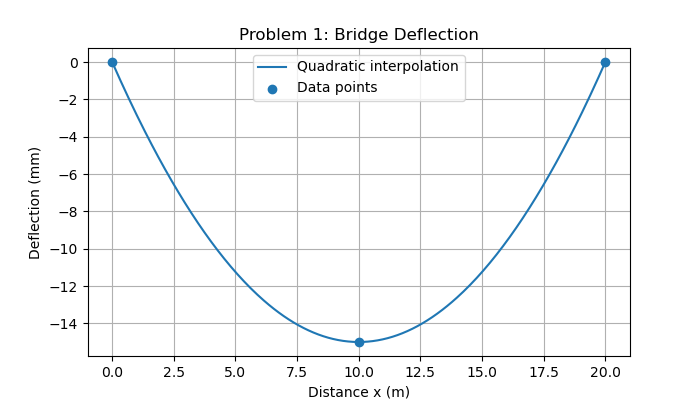

Problem 2 coefficients:
a = 0.12499999999999993, b = -19.999999999999996, c = 850.0
p(50) = 162.5 mPa·s
Linear interpolation at T=50: L(50) = 175.0 mPa·s
Difference = 12.5 mPa·s



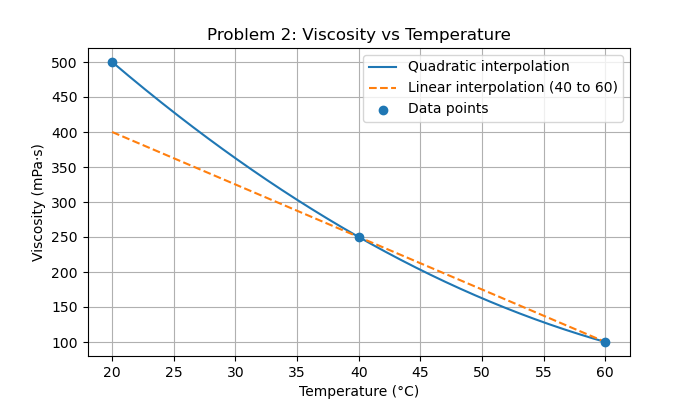

Problem 3 coefficients:
a3 = 0.0, a2 = 30.0, a1 = -19.999999999999993, a0 = 39.99999999999999
v(2.5) = 130.0 m/s
v(3.73) = 203.8 m/s



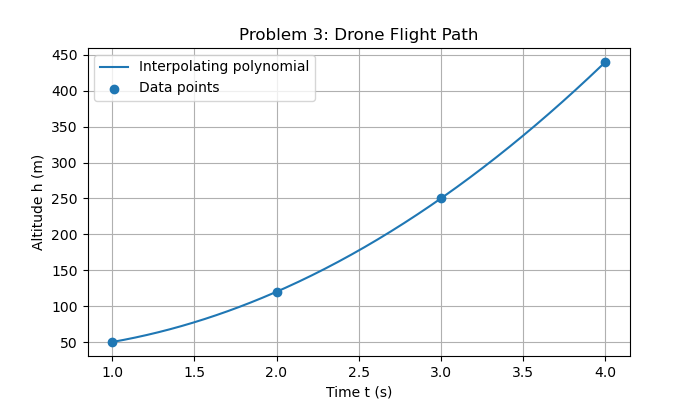

Problem 4:
P(1.5) = 0.9812500000000002 V



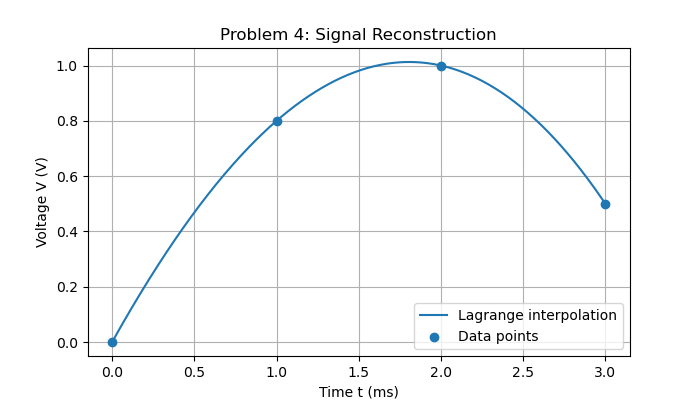

Problem 5 coefficients:
a = 0.0030000000000000014, b = -0.09500000000000001, c = 1.0
C(20) = 0.30000000000000027 mol/L
Roots of C(t) - 0.50 = 0: [25.          6.66666667]
Least squares line: y = -0.06500000000000003t + 0.9750000000000002
Least squares prediction at t=20: -0.3250000000000005 mol/L



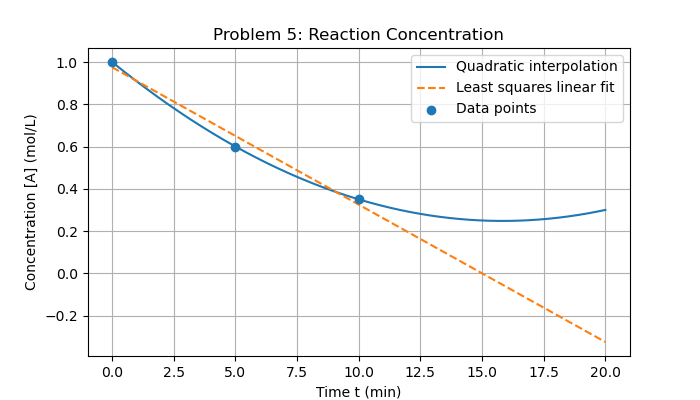

In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# DIRECT METHOD: Gaussian Elimination
# --------------------------------------------------
def gaussian_elimination(A, b):
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = len(b)

    # Forward elimination
    for k in range(n - 1):
        # Partial pivoting
        max_row = np.argmax(np.abs(A[k:, k])) + k
        if max_row != k:
            A[[k, max_row]] = A[[max_row, k]]
            b[[k, max_row]] = b[[max_row, k]]

        for i in range(k + 1, n):
            factor = A[i, k] / A[k, k]
            A[i, k:] = A[i, k:] - factor * A[k, k:]
            b[i] = b[i] - factor * b[k]

    # Back substitution
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - np.dot(A[i, i+1:], x[i+1:])) / A[i, i]

    return x


# --------------------------------------------------
# PROBLEM 1
# --------------------------------------------------
A1 = np.array([
    [0**2, 0, 1],
    [10**2, 10, 1],
    [20**2, 20, 1]
], dtype=float)

b1 = np.array([0, -15, 0], dtype=float)

a1, b1_coef, c1 = gaussian_elimination(A1, b1)

def P1(x):
    return a1*x**2 + b1_coef*x + c1

print("Problem 1 coefficients:")
print(f"a = {a1}, b = {b1_coef}, c = {c1}")
print(f"P(5) = {P1(5)} mm")
print(f"P(10) = {P1(10)} mm  # actual midpoint of beam span\n")

x_vals = np.linspace(0, 20, 300)
plt.figure(figsize=(7, 4))
plt.plot(x_vals, P1(x_vals), label="Quadratic interpolation")
plt.scatter([0, 10, 20], [0, -15, 0], zorder=3, label="Data points")
plt.xlabel("Distance x (m)")
plt.ylabel("Deflection (mm)")
plt.title("Problem 1: Bridge Deflection")
plt.grid(True)
plt.legend()
plt.show()


# --------------------------------------------------
# PROBLEM 2
# --------------------------------------------------
A2 = np.array([
    [20**2, 20, 1],
    [40**2, 40, 1],
    [60**2, 60, 1]
], dtype=float)

b2 = np.array([500, 250, 100], dtype=float)

a2, b2_coef, c2 = gaussian_elimination(A2, b2)

def P2(T):
    return a2*T**2 + b2_coef*T + c2

print("Problem 2 coefficients:")
print(f"a = {a2}, b = {b2_coef}, c = {c2}")
print(f"p(50) = {P2(50)} mPa·s")

# Linear interpolation between T=40 and T=60
m_lin = (100 - 250) / (60 - 40)
b_lin = 250 - m_lin * 40

def L2(T):
    return m_lin*T + b_lin

print(f"Linear interpolation at T=50: L(50) = {L2(50)} mPa·s")
print(f"Difference = {L2(50) - P2(50)} mPa·s\n")

T_vals = np.linspace(20, 60, 300)
plt.figure(figsize=(7, 4))
plt.plot(T_vals, P2(T_vals), label="Quadratic interpolation")
plt.plot(T_vals, L2(T_vals), linestyle="--", label="Linear interpolation (40 to 60)")
plt.scatter([20, 40, 60], [500, 250, 100], zorder=3, label="Data points")
plt.xlabel("Temperature (°C)")
plt.ylabel("Viscosity (mPa·s)")
plt.title("Problem 2: Viscosity vs Temperature")
plt.grid(True)
plt.legend()
plt.show()


# --------------------------------------------------
# PROBLEM 3
# --------------------------------------------------
A3 = np.array([
    [1**3, 1**2, 1, 1],
    [2**3, 2**2, 2, 1],
    [3**3, 3**2, 3, 1],
    [4**3, 4**2, 4, 1]
], dtype=float)

b3 = np.array([50, 120, 250, 440], dtype=float)

a3, b3_coef, c3, d3 = gaussian_elimination(A3, b3)

def H3(t):
    return a3*t**3 + b3_coef*t**2 + c3*t + d3

def V3(t):
    return 3*a3*t**2 + 2*b3_coef*t + c3

print("Problem 3 coefficients:")
print(f"a3 = {a3}, a2 = {b3_coef}, a1 = {c3}, a0 = {d3}")
print(f"v(2.5) = {V3(2.5)} m/s")
print(f"v(3.73) = {V3(3.73)} m/s\n")

t_vals = np.linspace(1, 4, 300)
plt.figure(figsize=(7, 4))
plt.plot(t_vals, H3(t_vals), label="Interpolating polynomial")
plt.scatter([1, 2, 3, 4], [50, 120, 250, 440], zorder=3, label="Data points")
plt.xlabel("Time t (s)")
plt.ylabel("Altitude h (m)")
plt.title("Problem 3: Drone Flight Path")
plt.grid(True)
plt.legend()
plt.show()


# --------------------------------------------------
# PROBLEM 4
# Lagrange Interpolation
# --------------------------------------------------
x4 = np.array([0, 1, 2, 3], dtype=float)
y4 = np.array([0.0, 0.8, 1.0, 0.5], dtype=float)

def lagrange_eval(x_data, y_data, x):
    total = 0
    n = len(x_data)
    for i in range(n):
        term = y_data[i]
        for j in range(n):
            if i != j:
                term *= (x - x_data[j]) / (x_data[i] - x_data[j])
        total += term
    return total

print("Problem 4:")
print(f"P(1.5) = {lagrange_eval(x4, y4, 1.5)} V\n")

t4_vals = np.linspace(0, 3, 300)
y4_vals = [lagrange_eval(x4, y4, t) for t in t4_vals]

plt.figure(figsize=(7, 4))
plt.plot(t4_vals, y4_vals, label="Lagrange interpolation")
plt.scatter(x4, y4, zorder=3, label="Data points")
plt.xlabel("Time t (ms)")
plt.ylabel("Voltage V (V)")
plt.title("Problem 4: Signal Reconstruction")
plt.grid(True)
plt.legend()
plt.show()


# --------------------------------------------------
# PROBLEM 5
# --------------------------------------------------
A5 = np.array([
    [0**2, 0, 1],
    [5**2, 5, 1],
    [10**2, 10, 1]
], dtype=float)

b5 = np.array([1.00, 0.60, 0.35], dtype=float)

a5, b5_coef, c5 = gaussian_elimination(A5, b5)

def C5(t):
    return a5*t**2 + b5_coef*t + c5

print("Problem 5 coefficients:")
print(f"a = {a5}, b = {b5_coef}, c = {c5}")
print(f"C(20) = {C5(20)} mol/L")

# Solve C(t) = 0.50
# a5*t^2 + b5_coef*t + c5 - 0.5 = 0
coeffs_root = [a5, b5_coef, c5 - 0.5]
roots = np.roots(coeffs_root)
print(f"Roots of C(t) - 0.50 = 0: {roots}")

# Least squares linear fit using formulas
x = np.array([0, 5, 10], dtype=float)
y = np.array([1.00, 0.60, 0.35], dtype=float)

n = len(x)
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_x2 = np.sum(x**2)
sum_xy = np.sum(x*y)

m = (n*sum_xy - sum_x*sum_y) / (n*sum_x2 - sum_x**2)
b_ls = (sum_y - m*sum_x) / n

def L5(t):
    return m*t + b_ls

print(f"Least squares line: y = {m}t + {b_ls}")
print(f"Least squares prediction at t=20: {L5(20)} mol/L\n")

t5_vals = np.linspace(0, 20, 400)
plt.figure(figsize=(7, 4))
plt.plot(t5_vals, C5(t5_vals), label="Quadratic interpolation")
plt.plot(t5_vals, L5(t5_vals), linestyle="--", label="Least squares linear fit")
plt.scatter([0, 5, 10], [1.00, 0.60, 0.35], zorder=3, label="Data points")
plt.xlabel("Time t (min)")
plt.ylabel("Concentration [A] (mol/L)")
plt.title("Problem 5: Reaction Concentration")
plt.grid(True)
plt.legend()
plt.show()